<a href="https://colab.research.google.com/github/JauharaPutri32/Praktikum-Struktur-Data/blob/main/Dijkstra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Instalasi Library #
!pip install networkx matplotlib

In [ ]:
# Struktur Data Graf dan Algoritma #
import heapq                      #Memproses node dengan jarak terkecil berikutnya secara efisien
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
  distances = {node: float('inf') for node in graph}  #Membuat dict untuk menyimpan jarak terpendek dari start ke setiap node
  #Di awal, semua node bernilai tak hingga karena belum mengetahui jarak sebenarnya
  distances[start] = 0                                #Jarak node awal ke node awal itu sendiri
  previous = {node: None for node in graph}           #Membuat dict untuk melacak jalur
  queue = [(0, start)]                                #Membuat priority queue berbentuk list yang berisi tuple (jarak, node)

  while queue:                                              #Melakukan perulangan selama antrean queue masih memiliki elemen
    current_distance, current_node = heapq.heappop(queue)   #heap.heappop(queue) : mengambil dan menghapus satu elemen yang memiliki nilai jarak terdekat
    #Hasil yang diambil tersimpan dengan angka jaraknya pada current_distance dan nama nodenya pada current_node

    for neighbor, weight in graph[current_node].items():    #Memeriksa tetangga beserta bobot jalurnya dari node saat ini
      distance = current_distance + weight                  #Menghitung jarak baru, jarak ke node saat ini + bobot ke node tetangga
      if distance < distances[neighbor]:                    #Memeriksa jalur baru apakah lebih pendek daripada jarak terpendek yang sudah tercatat sebelumnya
        distances[neighbor] = distance                      #Jika jalur baru lebih pendek, maka jarak terpendek diupdate
        previous[neighbor] = current_node                   #Mencatat jalur terbaik menuju tetangga
        heapq.heappush(queue, (distance, neighbor))         #Masukkan tetangga beserta jarak barunya ke dalam antrean prioritas untuk dieksplorasi lebih lanjut

  return distances, previous                                #Antrean kosong, fungsi mengembalikan daftar jarak terpendek dari titik awal ke semua titik
                                                            #dan silsilah node yang bisa digunakan untuk merekonstruksi jalur fisik yang dilewati

# Fungsi untuk Merekonstruksi Jalur #
def get_path(previous, target):  #previous : dict (node asal), target : node tujuan akhir yang ingin diketahui rute jalurnya
  path = []                      #Membuat list kosong, untuk membentuk rute utuh

  while target is not None:    #Perulangan mundur, berjalan selama target masih ada
    path.insert(0, target)     #Memasukkan node saat ini ke dalam list pada posisi paling depan
    target = previous[target]  #Memperbarui nilai target dengan node sebelumnya, mundur satu langkah
  return path                  #Fungsi mengembalikan list

# Visualisasi dengan networkx dan matplotlib #
def visualize_graph(graph, path=None):  #graph : data graph yang ingin digambar, path : rute jalur terpendek
  G = nx.DiGraph()                      #Membuat objek graph berarah kosong menggunakan library Networkx
  #DiGraph : graph berarah

  #Perulangan bersarang : membaca struktur data graph
  for node in graph:                              #Untuk setiap node pada graph
    for neighbor, weight in graph[node].items():  #Melihat node tetangga beserta bobotnya
      G.add_edge(node, neighbor, weight=weight)   #Menambahkan garis penghubung

  pos = nx.spring_layout(G)                            #Menghitung posisi koordinat(x,y) untuk setiap node
  edge_labels = nx.get_edge_attributes(G, 'weight')    #Mengambil semua data bobot untuk dijadikan label teks (angka menggantung di garis)

  plt.figure(figsize=(8, 6))                                      #Menyiapkan kanvas gambar menggunakan Matplotlib, lebar 8 inci dan tinggi 6 inci
  nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
  #with_labels=True : menampilkan nama node, arrows=True : menampilkan arah hubungan antar-node
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)   #Menggambar teks angka bobot di setiap garis penghubung

  #Garis tebal untuk jalur terpendek
  if path and len(path) > 1:                #Apabila path tidak bernilai None dan jumlah node di dalam jalur lebih dari 1
    path_edges = list(zip(path, path[1:]))  #Memasangkan node yang ada di dalam list rute untuk mendeteksi garis mana saja yang dilewati
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)
    #Menimpa gambar garis yang masuk daftar path_edges dengan warna merah, width=3 : ketebalan

    plt.title("Visualisasi Graf dan Jalur Terpendek")  #Memberi judul gambar garph
    plt.axis('off')                                    #Menghilangkan latar belakang diagram kartesius
    plt.show()                                         #Menampilkan gambar graph

Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


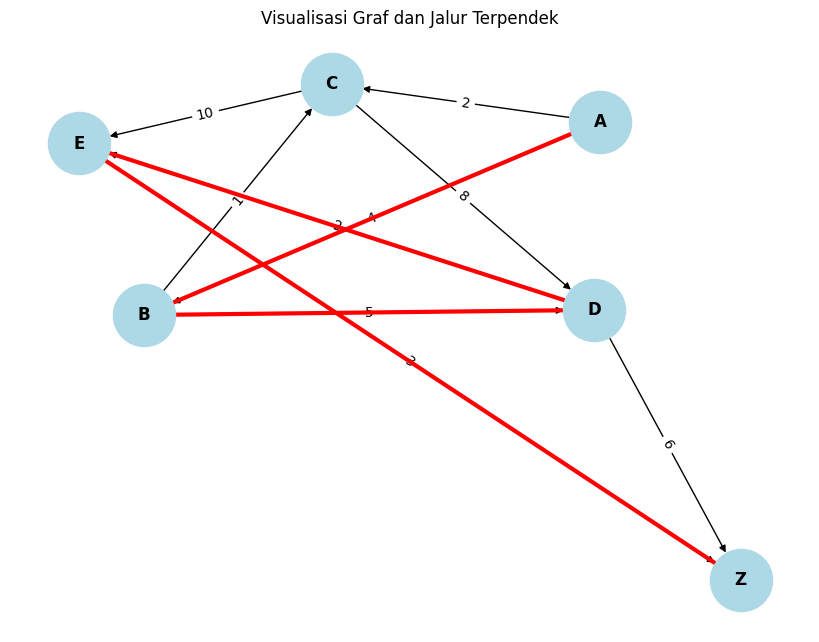

In [ ]:
# Penggunaan Lengkap #
#Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},  #{'Node':Bobot/Jarak}
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}                 #Tidak memiliki jalur keluar
}

#Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)
#Memanggil fungsi Dijkstra, menghitung jarak terpendek dari 'A' ke seluruh node
#distances : hasil, previous : jalur

#Rekonstruksi jalur
shortest_path = get_path(previous, end_node)                            #Mengurutkan rute dari 'Z' mundur ke belakang hingga 'A'
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")  #Menampilkan angka total jarak terpendek
print(f"Jalur: {' -> '.join(shortest_path)}")                           #Menampilkan rute jalan yang dilewati

#Visualisasi
visualize_graph(graph, path=shortest_path)  #Menggambar graph

Jarak dari A ke Z: 3
Jalur: A -> F -> Z


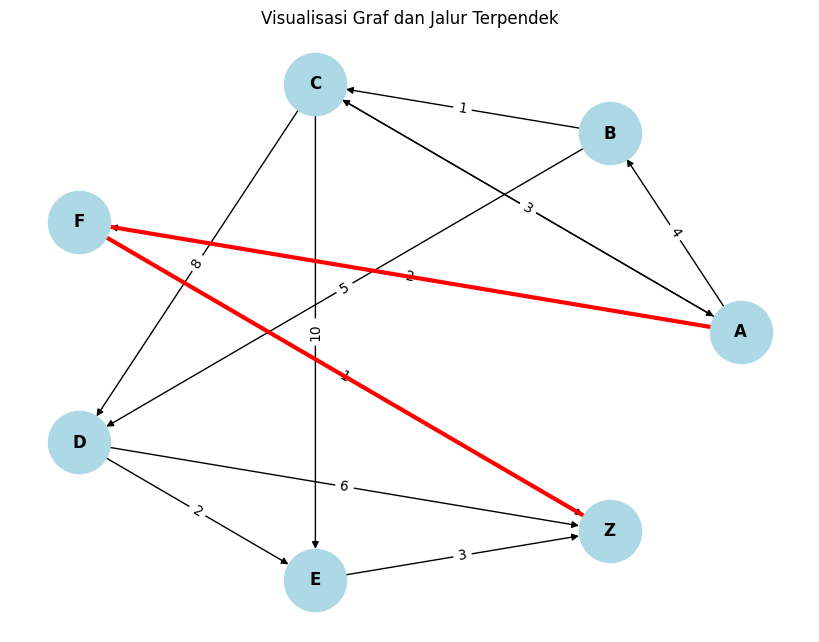

In [10]:
## LATIHAN / TUGAS ##

# Struktur Data Graf dan Algoritma #
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
  distances = {node: float('inf') for node in graph}
  distances[start] = 0
  previous = {node: None for node in graph}
  queue = [(0, start)]

  while queue:
    current_distance, current_node = heapq.heappop(queue)

    for neighbor, weight in graph[current_node].items():
      distance = current_distance + weight
      if distance < distances[neighbor]:
        distances[neighbor] = distance
        previous[neighbor] = current_node
        heapq.heappush(queue, (distance, neighbor))

  return distances, previous

# Fungsi untuk Merekonstruksi Jalur #
def get_path(previous, target):
  path = []
  while target is not None:
    path.insert(0, target)
    target = previous[target]
  return path

# Visualisasi dengan networkx dan matplotlib #
def visualize_graph(graph, path=None):
  G = nx.DiGraph()

  for node in graph:
    for neighbor, weight in graph[node].items():
      G.add_edge(node, neighbor, weight=weight)

  pos = nx.circular_layout(G) #Mengatur posisi koordinat setiap node agar tersusun rapi membentuk pola lingkaran
  edge_labels = nx.get_edge_attributes(G, 'weight')

  plt.figure(figsize=(8, 6))
  nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

  #Garis tebal untuk jalur terpendek
  if path and len(path) > 1:
    path_edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

#Definisi graf
graph = {
    'A': {'B': 4, 'C': 2, 'F': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'A': 3, 'D': 8, 'E': 10},  #Terdapat siklus bolak-balik A -> C -> A
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'F': {'Z': 1},                   #Penambahan simpul baru
    'Z': {}
}

#Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

#Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

#Visualisasi
visualize_graph(graph, path=shortest_path)